In [24]:
import json
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt


def flatten_result(d):
    """Flatten nested result dict into a flat dict."""
    flat = {}

    # top-level scalar metadata already embedded in JSON
    for key in ['type', 'epoch', 'run', 'forget_set_type', 'unlearning_item',
                'method', 'epoch_duration', 'total_unlearning_time_up_to_now', 'ToW']:
        if key in d:
            flat[key] = d[key]

    # nested metric dicts -> {split}_{metric} columns (e.g. forget_acc, retain_loss)
    for metric in ['acc', 'loss', 'entropy', 'm_entropy']:
        if metric in d:
            for split, val in d[metric].items():
                flat[f'{split}_{metric}'] = val

    # remaining nested result blocks -> {block}.{path} columns. threshold_MIA and
    # logistic_regression_MIA are now both flat {efficacy, attack_accuracy, auc, f1, ...} dicts;
    # outputs/weight_differences/residual_information/relearn_time are newer additions to the
    # result JSON -- json_normalize handles any of their nesting shapes generically.
    for block in ['threshold_MIA', 'logistic_regression_MIA', 'outputs',
                  'weight_differences', 'residual_information', 'relearn_time']:
        if block in d:
            block_flat = pd.json_normalize(d[block], sep='.')
            for col in block_flat.columns:
                flat[f'{block}.{col}'] = block_flat[col].iloc[0]

    return flat


def gather_results(results_folder,
                   epochs=None, classes=None, percents=None, runs=None, methods=None,
                   base=True, retrain=True):

    # collect all result json files
    all_files = []
    for root, dirs, files in os.walk(results_folder):
        for fname in files:
            if fname.endswith('.json') and 'config' not in fname:
                all_files.append(os.path.join(root, fname))

    def norm(f):
        return f.replace('\\', '/')

    if not base:
        all_files = [f for f in all_files if '/base/' not in norm(f)]
    if not retrain:
        all_files = [f for f in all_files if '/retrain/' not in norm(f)]

    if classes is not None:
        pattern = rf"class_({'|'.join(map(str, classes))})"
        all_files = [f for f in all_files if re.search(pattern, f)]
    if percents is not None:
        pattern = rf"percent_({'|'.join(map(str, percents))})"
        all_files = [f for f in all_files if re.search(pattern, f)]

    all_rows = []
    for f in all_files:
        with open(f) as fh:
            d = json.load(fh)

        flat = flatten_result(d)

        # class and percent from filename
        m = re.search(r'class_(\d+)', f)
        flat['class'] = int(m.group(1)) if m else -99
        m = re.search(r'percent_(\d+)', f)
        flat['percent'] = int(m.group(1)) if m else -99

        # fill sentinel epoch/run/method for base and retrain (not embedded in those JSONs)
        result_type = flat.get('type', 'unknown')
        if result_type == 'base':
            flat.setdefault('epoch', -99)
            flat.setdefault('run', -99)
            flat.setdefault('method', 'base')
        elif result_type == 'retrain':
            flat.setdefault('epoch', -98)
            flat.setdefault('method', 'retrain')
            m = re.search(r'retrain_run_(\d+)', norm(f))
            flat.setdefault('run', int(m.group(1)) if m else -99)

        all_rows.append(flat)

    if not all_rows:
        raise ValueError("No results - check settings")

    final_df = pd.DataFrame(all_rows)

    # post-load filters (epoch/run/method live in JSON, not path)
    if epochs is not None:
        final_df = final_df[final_df['epoch'].isin(epochs)]
    if runs is not None:
        final_df = final_df[final_df['run'].isin(runs)]
    if methods is not None:
        keep = set(methods) | {'base', 'retrain'}
        final_df = final_df[final_df['method'].isin(keep)]

    if final_df.empty:
        raise ValueError("No results after filtering - check settings")

    return final_df


# distinct marker shapes cycled across methods so each one is visually
# distinguishable by icon, not just by color
METHOD_MARKERS = ['o', 's', '^', 'D', 'P', 'X', 'v', '*', 'p', 'h', '<', '>']


def results_scatterplot(final_df, x_metric, y_metric,
                        color_by="method", marker_by="method",
                        base_color="black", retain_color="purple",
                        base_marker="o", retain_marker="X",
                        title=None, xlabel=None, ylabel=None,
                        grouped=True):

    plot_df = final_df
    x_err_col = y_err_col = None

    if grouped:
        # collapse the runs into one point per (method, epoch) -- also keep
        # color_by/marker_by in the grouping key in case they encode something
        # else (e.g. class), so every group still maps to a single color/marker
        group_cols = list(dict.fromkeys(["method", "epoch", color_by, marker_by]))
        agg = final_df.groupby(group_cols, dropna=False)[[x_metric, y_metric]].agg(["mean", "std"])
        agg.columns = ["_".join(c) for c in agg.columns]
        plot_df = agg.reset_index()
        x_err_col, y_err_col = f"{x_metric}_std", f"{y_metric}_std"
        plot_df = plot_df.rename(columns={f"{x_metric}_mean": x_metric, f"{y_metric}_mean": y_metric})

    unique_vals = sorted(plot_df[color_by].unique(), key=str)
    colors_list = plt.cm.tab20.colors
    palette_dict = {}
    color_idx = 0
    for val in unique_vals:
        if val == -99 or val == "base":
            palette_dict[val] = base_color
        elif val == -98 or val == "retrain":
            palette_dict[val] = retain_color
        else:
            palette_dict[val] = colors_list[color_idx % len(colors_list)]
            color_idx += 1

    unique_markers = sorted(plot_df[marker_by].unique(), key=str)
    marker_dict = {}
    marker_idx = 0
    for val in unique_markers:
        if val == -99 or val == "base":
            marker_dict[val] = base_marker
        elif val == -98 or val == "retrain":
            marker_dict[val] = retain_marker
        else:
            marker_dict[val] = METHOD_MARKERS[marker_idx % len(METHOD_MARKERS)]
            marker_idx += 1

    plt.clf()
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.35)
    ax = plt.gca()

    if grouped:
        for _, row in plot_df.iterrows():
            color = palette_dict.get(row[color_by], "gray")
            xerr = row[x_err_col] if pd.notna(row[x_err_col]) else 0
            yerr = row[y_err_col] if pd.notna(row[y_err_col]) else 0
            ax.errorbar(
                row[x_metric], row[y_metric],
                xerr=xerr, yerr=yerr,
                fmt="none", ecolor=color, elinewidth=1.2, capsize=3, alpha=0.6, zorder=1
            )

    sns.scatterplot(
        data=plot_df,
        x=x_metric,
        y=y_metric,
        hue=color_by,
        style=marker_by,
        palette=palette_dict,
        markers=marker_dict,
        s=80,
        alpha=0.7,
        edgecolor=None,
        ax=ax,
        zorder=2
    )
    ax.grid(True, alpha=0.3)
    plt.title(title if title is not None else f"{x_metric} vs. {y_metric}")
    plt.xlabel(xlabel if xlabel is not None else x_metric.capitalize().replace("_", " "))
    plt.ylabel(ylabel if ylabel is not None else y_metric.capitalize().replace("_", " "))
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["base" if l in ("-99", "-99.0") else "retrain" if l in ("-98", "-98.0") else l for l in labels]
    legend_title = color_by.capitalize() if color_by == marker_by else f"{color_by.capitalize()} / {marker_by.capitalize()}"
    ax.legend(title=legend_title, handles=handles, labels=new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.tight_layout()
    plt.show()

In [25]:
def results_table(results):
    """
    Summarise forget_acc, retain_acc, and test_acc for every method in `results`,
    showing mean ± std across runs.  For unlearning methods the last available
    epoch per run is used as the reported result.
    """
    metrics     = ['forget_acc', 'retain_acc', 'test_acc', 'ToW']
    col_labels  = {
        'forget_acc': 'Forget Acc (%)',
        'retain_acc': 'Retain Acc (%)',
        'test_acc':   'Test Acc (%)',
        'ToW': 'Tug-of-War (#)'
    }

    def fmt(mean, std=None):
        if std is None or pd.isna(std) or std == 0:
            return f"{mean:.2f}"
        return f"{mean:.2f} ± {std:.2f}"

    rows = []

    # --- base (single model, no std) ---
    base_df = results[results['type'] == 'base']
    if not base_df.empty:
        row = {'Method': 'base'}
        for m in metrics:
            row[col_labels[m]] = fmt(base_df[m].mean())
        rows.append(row)

    # --- retrain (mean ± std across retrain runs) ---
    retrain_df = results[results['type'] == 'retrain']
    if not retrain_df.empty:
        row = {'Method': 'retrain'}
        for m in metrics:
            row[col_labels[m]] = fmt(retrain_df[m].mean(), retrain_df[m].std())
        rows.append(row)

    # --- unlearning methods (last epoch per run, then mean ± std across runs) ---
    unlearn_df = results[results['type'] == 'unlearn'].dropna(subset=['method'])
    for method_name in unlearn_df['method'].unique():
        method_df = unlearn_df[unlearn_df['method'] == method_name].copy()
        last_epoch_per_run = method_df.groupby('run')['epoch'].max().rename('last_epoch')
        method_df = method_df.join(last_epoch_per_run, on='run')
        method_df = method_df[method_df['epoch'] == method_df['last_epoch']]

        row = {'Method': method_name}
        for m in metrics:
            row[col_labels[m]] = fmt(method_df[m].mean(), method_df[m].std())
        rows.append(row)

    return pd.DataFrame(rows).set_index('Method')


In [104]:
results = gather_results("results/seed_5", base=True, retrain=True) 
results

,type,epoch,run,forget_set_type,unlearning_item,method,epoch_duration,total_unlearning_time_up_to_now,ToW,forget_acc,...,threshold_MIA.correctness.forget_non_member,outputs.retrained_vs_unlearned.forget.absolute_distance,outputs.retrained_vs_unlearned.forget.l2_distance,outputs.retrained_vs_unlearned.forget.JS_divergence,outputs.retrained_vs_unlearned.retain.absolute_distance,outputs.retrained_vs_unlearned.test.absolute_distance,outputs.retrained_vs_unlearned.forget_test_avg.KL_divergence,outputs.unlearned.forget_vs_test.wasserstein_distance,class,percent
0,unlearn,10,2,random,0.1,scrub,11.473243,115415.956259,0.929666,94.76,...,0.0524,1.812274,1.253672,0.620937,1.797712,0.160388,13.993875,0.238502,-99,-99
1,unlearn,5,2,random,0.1,scrub,11.401358,58332.325220,0.888540,90.66,...,0.0934,1.791430,1.228176,0.611377,1.793194,0.217908,12.552148,0.198019,-99,-99
2,unlearn,3,2,random,0.1,GA,1.529175,4483.595133,0.913774,99.92,...,0.0008,1.804992,1.261356,0.621585,1.801231,0.135623,13.181892,0.335792,-99,-99
3,unlearn,5,2,random,0.1,GA,1.450152,7386.019468,0.915321,99.82,...,0.0018,1.811781,1.266477,0.623626,1.797494,0.135653,13.188390,0.334654,-99,-99
4,unlearn,1,2,random,0.1,bad_teacher,12.137320,12137.319803,0.920792,98.84,...,0.0116,1.787341,1.167779,0.586674,1.794436,0.397048,4.426111,0.157793,-99,-99
5,unlearn,2,2,random,0.1,bad_teacher,12.123764,24261.083841,0.922735,99.12,...,0.0088,1.792746,1.176248,0.590248,1.794351,0.378794,4.621039,0.166195,-99,-99
6,unlearn,10,2,random,0.1,NegGrad_plus,17.502722,177212.026119,0.916389,99.86,...,0.0014,1.803372,1.259902,0.621053,1.802468,0.135835,14.132788,0.364939,-99,-99
7,unlearn,5,2,random,0.1,NegGrad_plus,17.977517,89814.134836,0.916603,99.76,...,0.0024,1.790056,1.250792,0.616335,1.799187,0.135899,13.672333,0.348206,-99,-99
8,unlearn,10,2,random,0.1,FT,9.693877,96736.238956,0.915503,99.90,...,0.0010,1.795879,1.255731,0.618719,1.799894,0.133851,13.935970,0.349279,-99,-99
9,unlearn,5,2,random,0.1,FT,9.693513,48944.514275,0.914539,99.88,...,0.0012,1.805790,1.262282,0.622383,1.795696,0.131079,13.519527,0.346122,-99,-99


In [105]:
# names of all output columns
for c in results.columns:
    if "outputs" in c:
        print(c)

outputs.retrained_vs_unlearned.forget.absolute_distance
outputs.retrained_vs_unlearned.forget.l2_distance
outputs.retrained_vs_unlearned.forget.JS_divergence
outputs.retrained_vs_unlearned.retain.absolute_distance
outputs.retrained_vs_unlearned.test.absolute_distance
outputs.retrained_vs_unlearned.forget_test_avg.KL_divergence
outputs.unlearned.forget_vs_test.wasserstein_distance


In [114]:
# names of all output columns
for c in results.columns:
    if "MIA" in c:
        print(c)

threshold_MIA.efficacy
threshold_MIA.attack_accuracy
threshold_MIA.auc
threshold_MIA.f1
threshold_MIA.avg_member_probability_forget
threshold_MIA.n_forget_pred_member
threshold_MIA.n_forget_pred_non_member
logistic_regression_MIA.efficacy
logistic_regression_MIA.attack_accuracy
logistic_regression_MIA.auc
logistic_regression_MIA.f1
logistic_regression_MIA.avg_member_probability_forget
logistic_regression_MIA.n_forget_pred_member
logistic_regression_MIA.n_forget_pred_non_member
threshold_MIA.class.confidence.retain_test_member
threshold_MIA.class.confidence.forget_non_member
threshold_MIA.class.entropy.retain_test_member
threshold_MIA.class.entropy.forget_non_member
threshold_MIA.class.m_entropy.retain_test_member
threshold_MIA.class.m_entropy.forget_non_member
threshold_MIA.no_class.confidence.retain_test_member
threshold_MIA.no_class.confidence.forget_non_member
threshold_MIA.no_class.entropy.retain_test_member
threshold_MIA.no_class.entropy.forget_non_member
threshold_MIA.no_class.m_

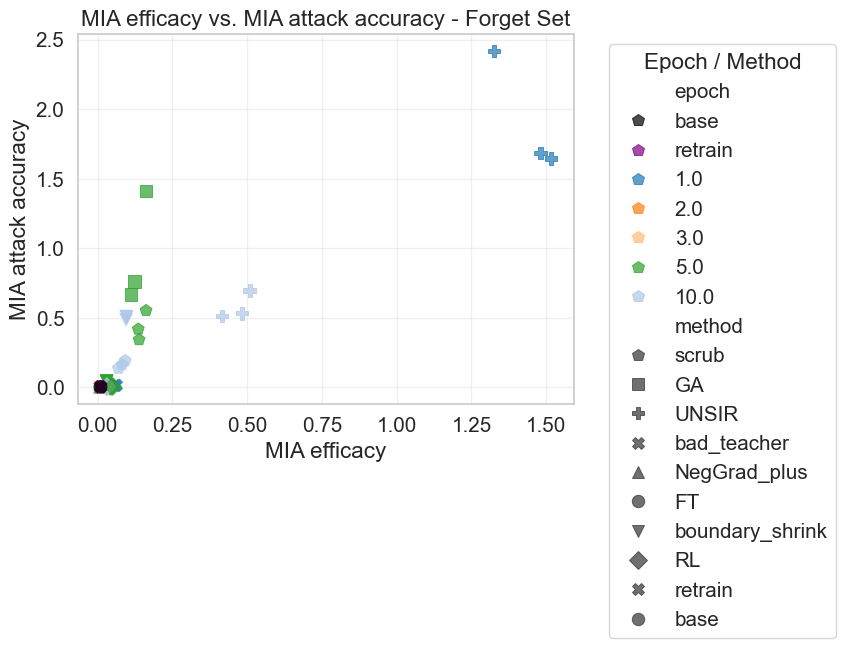

KeyError: 'Column not found: threshold_MIA.efficacy'

In [131]:
# mean +-std for each method (8 crossses)

results = gather_results("results/seed_4", base=True, retrain=True)
results_scatterplot(
    results, 
    x_metric = "retain_entropy", 
    y_metric = "retain_m_entropy",
    title = "MIA efficacy vs. MIA attack accuracy - Forget Set",
    xlabel = "MIA efficacy",
    ylabel = "MIA attack accuracy",
    grouped = False,
    color_by = "epoch"
    )

results_barplot(
    results, 
    "threshold_MIA.efficacy",
    title="MIA efficacy (share of forget points labeled non-members)", 
    ylabel=None,
    base_color="black", 
    retain_color="purple"
    )

results_barplot(
    results, 
    "outputs.retrain_vs_unlearned.forget.JS_divergence",
    title="Absolute distance, forget set", 
    ylabel=None,
    base_color="black", 
    retain_color="purple"
    )

In [ ]:
results = gather_results("results/seed_5000", base=True, retrain=True)
results_table(results)

,Forget Acc (%),Retain Acc (%),Test Acc (%),Tug-of-War (#)
Method,,,,
base,99.86,99.84,92.93,nan
retrain,91.45 ± 0.23,99.84 ± 0.02,92.69 ± 0.12,nan
FT,99.86 ± 0.07,99.81 ± 0.03,92.83 ± 0.05,0.91 ± 0.00
GA,99.88 ± 0.05,99.87 ± 0.02,92.96 ± 0.01,0.91 ± 0.00
NegGrad_plus,99.77 ± 0.06,99.80 ± 0.08,92.79 ± 0.15,0.92 ± 0.00
RL,99.64 ± 0.03,99.72 ± 0.01,92.70 ± 0.08,0.92 ± 0.00
boundary_shrink,99.73 ± 0.10,99.72 ± 0.03,92.58 ± 0.03,0.92 ± 0.00
bad_teacher,98.43 ± 0.37,99.32 ± 0.11,90.82 ± 1.09,0.91 ± 0.01
scrub,94.27 ± 0.38,96.96 ± 0.25,91.27 ± 0.25,0.93 ± 0.00


In [ ]:
# import torch

# def entropy_chart(dataset = "forget"):

#     fig, ax = plt.subplots()

#     ax.hist(torch.log(base_out[dataset]["entropies"]).numpy(),      bins=50, alpha=0.6, label="base")
#     ax.hist(torch.log(unlearned_out[dataset]["entropies"]).numpy(), bins=50, alpha=0.6, label="unlearned")
#     ax.hist(torch.log(retrained_out[dataset]["entropies"]).numpy(), bins=50, alpha=0.6, label="retrained")

#     ax.set_xlabel("Entropy")
#     ax.set_ylabel("Count")
#     ax.set_title(f"Entropy Distribution - {dataset}")
#     ax.legend()
#     plt.tight_layout()
#     plt.show()

# entropy_chart("forget")
# entropy_chart("retain")
# entropy_chart("test")

In [ ]:
def compare_to_literature(results_subfolder, method,
                           filepath="results_to_replicate.txt"):
    """
    Parse results_to_replicate.txt, filter to `method`, and plot a grouped bar
    chart of forget / retain / test accuracy per paper, with your own results
    from `results_subfolder` appended as 'ours' on the right.

    Parsing rules for results_to_replicate.txt:
      - Lines whose first comma-separated field starts with a capital letter are
        data rows (paper, method, hyperparams..., values).
      - The accuracy values are the trailing chunks separated from the hyperparams
        by 3+ spaces; they match the pattern  `number [± number]`.
      - Continuation lines (extra hyperparam detail) are skipped automatically
        because they don't start with a capital-letter paper name.
    """
    val_re = re.compile(r'^(\d+(?:\.\d+)?)\s*(?:[±+]\s*(\d+(?:\.\d+)?))?$')

    # ── 1. Parse literature entries for this method ───────────────────────── #
    entries = []
    with open(filepath) as fh:
        for line in fh:
            s = line.strip()
            if not s or s[0] in ('#', '~', '{', '}'):
                continue
            cols = s.split(',', 2)
            if len(cols) < 2:
                continue
            paper = cols[0].strip()
            meth  = cols[1].strip()
            # skip continuation / hyperparam-only lines (no capital-letter paper name)
            if not paper or not paper[0].isupper():
                continue
            if meth.lower() != method.lower():
                continue

            rest   = cols[2] if len(cols) > 2 else ''
            # split on 3+ spaces/tabs to separate the hyperparam blob from the value columns
            chunks = [c.strip().rstrip(',') for c in re.split(r'[\t ]{3,}', rest) if c.strip()]

            acc = []
            for chunk in chunks:
                hit = val_re.match(chunk)
                if hit:
                    acc.append((float(hit.group(1)),
                                float(hit.group(2)) if hit.group(2) else None))

            if not acc:
                continue

            entries.append({
                'label':       paper,
                'forget_mean': acc[0][0]  if len(acc) > 0 else None,
                'forget_std':  acc[0][1]  if len(acc) > 0 else None,
                'retain_mean': acc[1][0]  if len(acc) > 1 else None,
                'retain_std':  acc[1][1]  if len(acc) > 1 else None,
                'test_mean':   acc[2][0]  if len(acc) > 2 else None,
                'test_std':    acc[2][1]  if len(acc) > 2 else None,
            })

    if not entries:
        print(f"No literature entries found for method '{method}'.")
        return

    # ── 2. Append own results (last epoch per run, mean ± std across runs) ── #
    try:
        own_df = gather_results(results_subfolder, base=False, retrain=False, methods=[method])
        own_df = own_df[(own_df['type'] == 'unlearn') & (own_df['method'] == method)].copy()
        if not own_df.empty:
            last_ep = own_df.groupby('run')['epoch'].transform('max')
            own_df  = own_df[own_df['epoch'] == last_ep]
            own_entry = {'label': 'ours'}
            for metric in ('forget', 'retain', 'test'):
                vals = own_df[f'{metric}_acc']
                own_entry[f'{metric}_mean'] = vals.mean()
                own_entry[f'{metric}_std']  = vals.std()
            entries.append(own_entry)
    except Exception as e:
        print(f"Note: could not load own results from '{results_subfolder}': {e}")

    # ── 3. Plot ───────────────────────────────────────────────────────────── #
    labels  = [e['label'] for e in entries]
    metrics = [('forget', 'Forget Acc', '#e74c3c'),
               ('retain', 'Retain Acc', '#2ecc71'),
               ('test',   'Test Acc',   '#3498db')]

    x       = np.arange(len(labels))
    w       = 0.25
    offsets = np.array([-1, 0, 1]) * w

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 1.8), 6))

    for offset, (metric, mlabel, color) in zip(offsets, metrics):
        means = np.array([e.get(f'{metric}_mean', np.nan) for e in entries], dtype=float)
        stds  = np.array([e.get(f'{metric}_std')  or 0.0  for e in entries], dtype=float)
        bars  = ax.bar(x + offset, means, w,
                       label=mlabel, color=color, alpha=0.8,
                       yerr=stds, capsize=4, error_kw=dict(elinewidth=1.2, ecolor='#333'))

        for bar, mean, std in zip(bars, means, stds):
            if np.isnan(mean):
                continue
            label_text = f"{mean:.1f}\n(±{std:.1f})" if std else f"{mean:.1f}"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + 1.5,
                label_text,
                ha='center', va='bottom', fontsize=9, color='#222'
            )

    ax.set_xticks(x)
    tick_labels = ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    if labels[-1] == 'ours':
        tick_labels[-1].set_fontweight('bold')

    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 125)
    ax.set_title(f"Literature vs Ours — {method}")
    ax.legend(loc='upper right', ncols=3)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


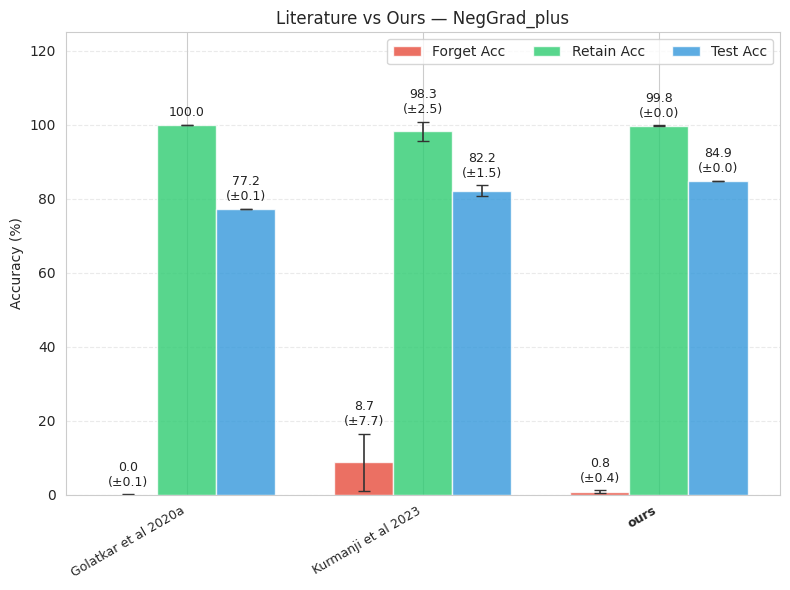

In [ ]:
# compare_to_literature("results/seed_6", method = "FT")

In [45]:
def results_barplot(final_df, metric,
                    title=None, ylabel=None,
                    base_color="black", retain_color="purple"):
    """
    Bar chart of a single metric, one bar per (method, epoch) group, with the
    mean and std across runs computed within each group and printed above the bar.
    """
    agg = final_df.groupby(["method", "epoch"], dropna=False)[metric].agg(["mean", "std"]).reset_index()

    # order: base, then retrain, then unlearning methods (alphabetical) by ascending epoch
    def sort_key(row):
        if row["method"] == "base":
            return (-2, "", row["epoch"])
        if row["method"] == "retrain":
            return (-1, "", row["epoch"])
        return (0, row["method"], row["epoch"])
    agg = agg.loc[agg.apply(sort_key, axis=1).sort_values().index].reset_index(drop=True)

    def label_for(row):
        if row["method"] in ("base", "retrain"):
            return row["method"]
        return f"{row['method']}\n(epoch {int(row['epoch'])})"
    agg["label"] = agg.apply(label_for, axis=1)

    # colors: fixed for base/retrain, cycled per unlearning method (same color across its epochs)
    colors_list = plt.cm.tab20.colors
    method_color = {}
    color_idx = 0
    for m in agg["method"]:
        if m in ("base", "retrain", *method_color):
            continue
        method_color[m] = colors_list[color_idx % len(colors_list)]
        color_idx += 1

    def color_for(row):
        if row["method"] == "base":
            return base_color
        if row["method"] == "retrain":
            return retain_color
        return method_color[row["method"]]
    bar_colors = [color_for(row) for _, row in agg.iterrows()]

    plt.clf()
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.35)
    fig, ax = plt.subplots(figsize=(max(8, len(agg) * 1.1), 6))

    x = list(range(len(agg)))
    means = agg["mean"].tolist()
    stds = agg["std"].fillna(0).tolist()

    bars = ax.bar(x, means, color=bar_colors, alpha=0.85, yerr=stds, capsize=4,
                  error_kw=dict(elinewidth=1.2, ecolor="#333"))

    for bar, mean, std in zip(bars, means, stds):
        label_text = f"{mean:.3f}\n(±{std:.3f})" if std else f"{mean:.3f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std,
            label_text,
            ha="center", va="bottom", fontsize=11
        )

    ax.set_xticks(x)
    ax.set_xticklabels(agg["label"], rotation=30 if len(agg) > 6 else 0, ha="right" if len(agg) > 6 else "center")
    ax.set_ylabel(ylabel if ylabel is not None else metric.capitalize().replace("_", " "))
    ax.set_title(title if title is not None else f"{metric.capitalize().replace('_', ' ')} by Method / Epoch")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
r